In [154]:
import matplotlib.pyplot as plt
import numpy as np
import copy

def find_center(ll):
    center = np.zeros(2)

    node = ll.head
    for i in range(ll.size):
        center += node.position
        node = node.next

    return center/ll.size
    
def scale_from_center(ll, scale):
    center = find_center(ll)

    node = ll.head
    for i in range(ll.size):
        node.position = (node.position - center)*scale + center
        node = node.next

class Node:
    def __init__(self, position, prev_node=None, next_node=None):
        self.position = copy.deepcopy(position)
        self.prev = prev_node
        self.next = next_node

class List:
    def __init__(self, points):
        # Construct the linked list from a list of points
        
        self.size = len(points)
        node_points = [Node(point) for point in points]
        
        N = self.size
        self.head = node_points[0]
        for i in range(N):
            p = (i-1+N)%N
            n = (i+1)%N
            node_points[i].prev = node_points[p]
            node_points[i].next = node_points[n]

    def to_array(self):
        node = self.head
        nodes = []
        for i in range(self.size):
            nodes.append(node.position)
            node = node.next

        return nodes

    def print(self):
        node = self.head
        print("Printing list")
        for i in range(self.size):
            print(node.position)
            node = node.next

    def copy(self):
        points = self.to_array()
        return List(points)

        
    def delete_node(self, node):
        node.next.prev = node.prev
        node.prev.next = node.next
        if node == self.head:
            self.head = node.next
            self.size -= 1
        


def merge_second_into_first(list1, node1_index, list2, node2_index):
    node1 = list1.head
    for i in range(node1_index):
        node1 = node1.next
    
    node2 = list2.head
    for i in range(node2_index):
        node2 = node2.next


    copied_node1 = Node(copy.deepcopy(node1.position), node1, node1.next)
    node1.next.prev = copied_node1
    node1.next = copied_node1
    list1.size += 1

    copied_node2 = Node(copy.deepcopy(node2.position), node2, node2.next)
    node2.next.prev = copied_node2
    node2.next = copied_node2
    list2.size += 1

    a = 0.05
    unit = copied_node1.next.position - copied_node1.position
    unit = unit/np.linalg.norm(unit)
    copied_node1.position += unit*a
    
    unit = node1.prev.position - node1.position
    unit = unit/np.linalg.norm(unit)
    node1.position += unit*a

    
    unit = copied_node2.next.position - copied_node2.position
    unit = unit/np.linalg.norm(unit)
    copied_node2.position += unit*a
    
    unit = node2.prev.position - node2.position
    unit = unit/np.linalg.norm(unit)
    node2.position += unit*a

    copied_node1.prev = node2
    node2.next = copied_node1

    node1.next = copied_node2
    copied_node2.prev = node1
    

    list1.size += list2.size
    list2.size = 0
    list2.head = None

def prune_once(ll):
    # Check for coinciding points
    tol = 1e-1

    
    node = ll.head
    prev_position = node.prev.position
    for i in range(ll.size):

        pos = node.position

        if np.linalg.norm(pos - prev_position) < tol:
            ll.delete_node(node)
            return True

        node = node.next
        prev_position = pos


    for i in range(ll.size):
        unit1 = node.position - node.prev.position
        unit1 = unit1/np.linalg.norm(unit1)
        unit2 = node.position - node.next.position
        unit2 = unit2/np.linalg.norm(unit2)
        if np.linalg.norm(unit1 - unit2) < tol:
            ll.delete_node(node)
            return True

        node = node.next
        
    return False

center [0.33333333 0.33333333]


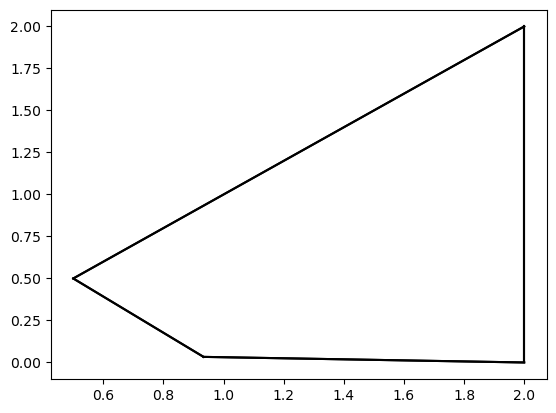

In [152]:

square = [np.array([0.0, 0.0]), np.array([2.0, 0.0]), 
          np.array([2.0, 2.0]), np.array([0.5, 0.5]), np.array([0.0, 1.0])]

t1 = [np.array([0.0, 0.0]), np.array([0.0, 1.0]), np.array([1.0, 0.0])]

list1 = List(square)
list2 = List(t1)
list3 = list2.copy()
scale_from_center(list3, 0.9)

merge_second_into_first(list1, 0, list3, 0)
for i in range(6):
    prune_once(list1)


fig, ax = plt.subplots()

node = list1.head
for i in range(list1.size):
    x1, y1 = node.position
    x2, y2 = node.next.position
    ax.plot([x1, x2], [y1, y2], '-', color='k')
    node = node.next

# node = list3.head
# for i in range(list3.size):
#     x1, y1 = node.position
#     x2, y2 = node.next.position
#     ax.plot([x1, x2], [y1, y2], 'o-', color='r')
#     node = node.next